# **Importaciones y configuracion global**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. CONFIGURACION
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo activo: {device}")

MODEL_NAME = "dccuchile/bert-base-spanish-wwm-uncased"
NUM_CLASES = 4
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3

Dispositivo activo: cuda


# **Transformacion a vectores**

In [ ]:
# 2. DATASET Y PREPROCESAMIENTO
class CenevalDataset(Dataset):
    def __init__(self, data, model_name, max_length):
        self.data = data
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        texto = str(self.data.iloc[idx]['texto'])
        etiqueta = self.data.iloc[idx]['etiqueta']
        encoding = self.tokenizer(
            texto, add_special_tokens=True, max_length=self.max_length,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(etiqueta, dtype=torch.long)
        }


df_full = pd.read_csv("/content/dataset_ceneval_super_final.csv")
full_dataset = CenevalDataset(df_full, MODEL_NAME, MAX_LENGTH)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Datos listos. Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Datos listos. Train: 1616, Val: 202, Test: 202


# **EDA**

🔍 INICIANDO ANÁLISIS EXPLORATORIO DE DATOS (EDA)

--- 1. Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   texto        2020 non-null   object
 1   respuesta    2020 non-null   object
 2   etiqueta     2020 non-null   int64 
 3   area_origen  2020 non-null   object
dtypes: int64(1), object(3)
memory usage: 63.3+ KB
None

--- 2. Conteo de Valores Nulos ---
texto          0
respuesta      0
etiqueta       0
area_origen    0
dtype: int64


/tmp/ipykernel_633/800566673.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_full, x='etiqueta', ax=axes[0], palette="viridis")


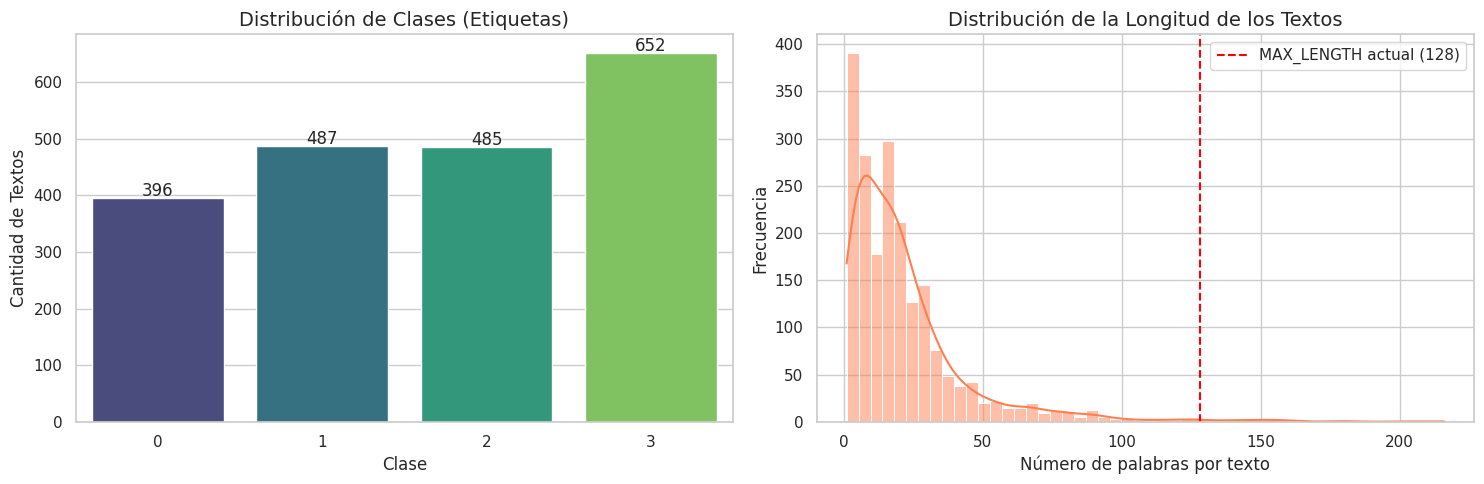


--- 3. Estadísticas de Longitud de Textos (Palabras) ---
count    2020.000000
mean       21.931683
std        23.352740
min         1.000000
25%         7.000000
50%        16.000000
75%        27.000000
max       216.000000
Name: texto, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


print("="*50)
print(" INICIANDO ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*50)

# 1. INSPECCIÓN BÁSICA Y VALORES NULOS
print("\n--- 1. Información General ---")
print(df_full.info())

print("\n--- 2. Conteo de Valores Nulos ---")
nulos = df_full.isnull().sum()
print(nulos)
if nulos.sum() > 0:
    print(" ATENCIÓN: Se encontraron valores nulos. Limpiando el dataset...")
    df_full = df_full.dropna().reset_index(drop=True)

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 3. DISTRIBUCIÓN DE CLASES (BALANCEO)
sns.countplot(data=df_full, x='etiqueta', ax=axes[0], palette="viridis")
axes[0].set_title('Distribución de Clases (Etiquetas)', fontsize=14)
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad de Textos', fontsize=12)

# Añadir los números sobre las barras
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center', xytext = (0, 5),
                     textcoords = 'offset points')

# 4. ANÁLISIS DE LONGITUD DE TEXTO (Para justificar MAX_LENGTH)
# Calculamos la cantidad de palabras por texto (aproximación rápida a tokens)
longitudes = df_full['texto'].astype(str).apply(lambda x: len(x.split()))

sns.histplot(longitudes, bins=50, kde=True, ax=axes[1], color="coral")
axes[1].axvline(x=128, color='red', linestyle='--', label='MAX_LENGTH actual (128)')
axes[1].set_title('Distribución de la Longitud de los Textos', fontsize=14)
axes[1].set_xlabel('Número de palabras por texto', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

# Resumen estadístico de la longitud
print("\n--- 3. Estadísticas de Longitud de Textos (Palabras) ---")
print(longitudes.describe())

# **Arquitectura de modelos**

In [ ]:
# 3. ARQUITECTURAS (3 Modelos)
class BERT_Linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.out = nn.Linear(768, NUM_CLASES)

    def forward(self, ids, mask):
        # Paso de argumentos explícito y corrección de 'pooler_output'
        return self.out(self.bert(input_ids=ids, attention_mask=mask).pooler_output)

class BERT_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.conv = nn.Conv1d(768, 128, kernel_size=3, padding=1)
        self.out = nn.Linear(128, NUM_CLASES)

    def forward(self, ids, mask):
        x = self.bert(input_ids=ids, attention_mask=mask).last_hidden_state.permute(0, 2, 1)
        x = torch.relu(self.conv(x))
        return self.out(torch.max(x, dim=2)[0])

class BERT_LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.lstm = nn.LSTM(768, 128, batch_first=True, bidirectional=True)
        self.out = nn.Linear(256, NUM_CLASES)

    def forward(self, ids, mask):
        x = self.bert(input_ids=ids, attention_mask=mask).last_hidden_state
        _, (h, _) = self.lstm(x)
        return self.out(torch.cat((h[-2,:,:], h[-1,:,:]), dim=1))

# **Logica operacional**

In [ ]:
# 4. FUNCION DE ENTRENAMIENTO Y EVALUACION (Definiciones)
def train_model(model, name):
    print(f"\n--- Entrenando {name} ---")
    optimizer = AdamW(model.parameters(), lr=2e-5)

    # Instanciar la función de pérdida una sola vez mejora el rendimiento
    criterio = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        t_loss = 0
        for batch in tqdm(train_loader):
            optimizer.zero_grad()
            out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            loss = criterio(out, batch['labels'].to(device))
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss, correct = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
                v_loss += criterio(out, batch['labels'].to(device)).item()
                correct += (out.argmax(1) == batch['labels'].to(device)).sum().item()

        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss/len(val_loader))
        history['val_acc'].append(correct/len(val_ds))
        print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {history['val_acc'][-1]:.4f}")

    return history

def evaluate_test(model):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            out = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
            y_true.extend(batch['labels'].tolist())
            y_pred.extend(out.argmax(1).tolist())

    print("\n--- REPORTE FINAL EN TEST ---")
    print(classification_report(y_true, y_pred))

    # Sintaxis actualizada para versiones recientes de sklearn
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.show()

# **Entrenamiento**

In [ ]:
# 5. EJECUCIÓN DEL ENTRENAMIENTO

# Paso 1: Instanciamos el modelo en una variable para conservar su estado
modelo_lineal = BERT_Linear()

# Paso 2: Lo enviamos a la memoria de la GPU globalmente
modelo_lineal = modelo_lineal.to(device)

# Paso 3: Entrenamos ESA instancia específica
h_linear = train_model(modelo_lineal, "Modelo 1: Linear")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training o


--- Entrenando Modelo 1: Linear ---


100%|██████████| 101/101 [00:36<00:00,  2.78it/s]


Epoch 1/3 | Val Acc: 0.7079


100%|██████████| 101/101 [00:40<00:00,  2.51it/s]


Epoch 2/3 | Val Acc: 0.8168


100%|██████████| 101/101 [00:38<00:00,  2.63it/s]


Epoch 3/3 | Val Acc: 0.8119


# **Resultados y Test Final**

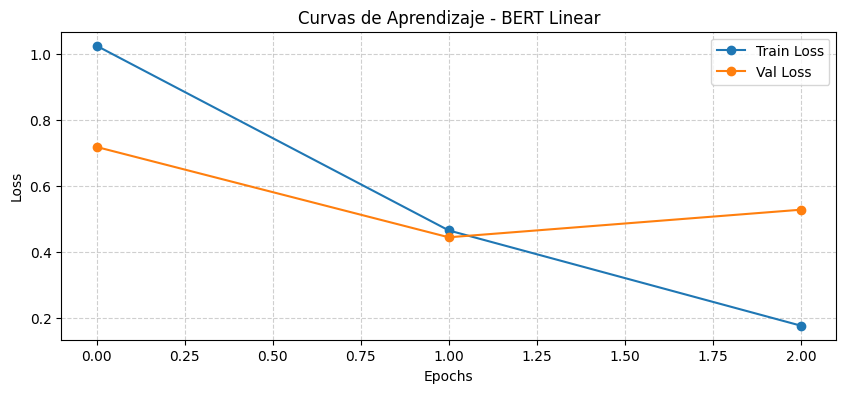


--- REPORTE FINAL EN TEST ---
              precision    recall  f1-score   support

           0       0.70      0.90      0.79        41
           1       0.87      0.54      0.67        48
           2       0.76      0.72      0.74        54
           3       0.76      0.88      0.82        59

    accuracy                           0.76       202
   macro avg       0.77      0.76      0.75       202
weighted avg       0.78      0.76      0.76       202



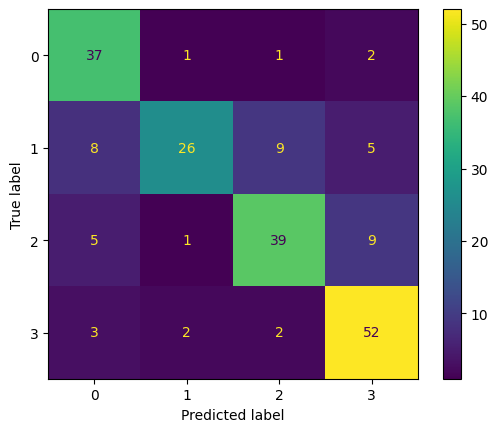

In [ ]:
# 6. VISUALIZACION DE CURVAS Y EVALUACION FINAL

# Curvas de Aprendizaje
plt.figure(figsize=(10,4))
plt.plot(h_linear['train_loss'], label='Train Loss', marker='o')
plt.plot(h_linear['val_loss'], label='Val Loss', marker='o')
plt.title("Curvas de Aprendizaje - BERT Linear")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Evaluación usando el modelo YA ENTRENADO
evaluate_test(modelo_lineal)


INICIANDO FLUJO PARA BERT_CNN


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training o


--- Entrenando Modelo 2: CNN ---


100%|██████████| 101/101 [00:45<00:00,  2.24it/s]


Epoch 1/3 | Val Acc: 0.7129


100%|██████████| 101/101 [00:40<00:00,  2.47it/s]


Epoch 2/3 | Val Acc: 0.8020


100%|██████████| 101/101 [00:42<00:00,  2.38it/s]


Epoch 3/3 | Val Acc: 0.8416


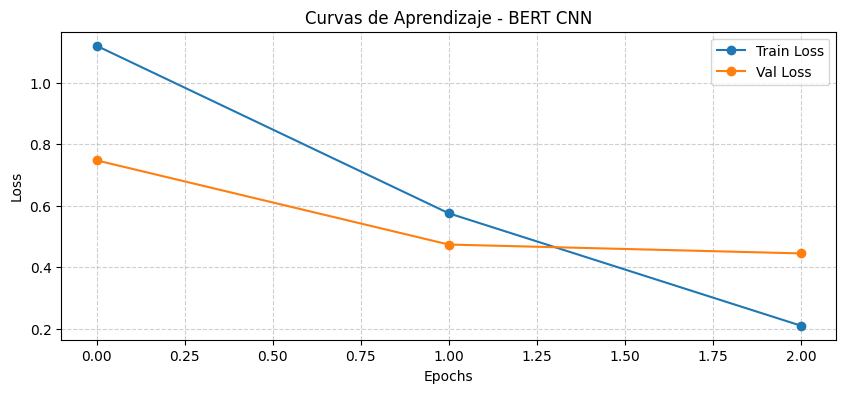


--- REPORTE FINAL EN TEST ---
              precision    recall  f1-score   support

           0       0.84      0.76      0.79        41
           1       0.77      0.83      0.80        48
           2       0.75      0.74      0.75        54
           3       0.77      0.78      0.77        59

    accuracy                           0.78       202
   macro avg       0.78      0.78      0.78       202
weighted avg       0.78      0.78      0.78       202



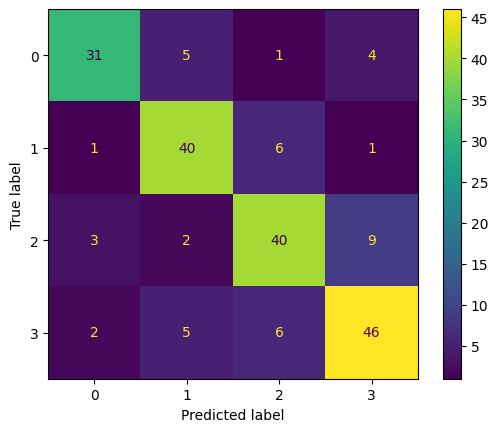

In [ ]:
# --- ENTRENAMIENTO Y EVALUACIÓN: BERT CNN ---
print("\n" + "="*40)
print("INICIANDO FLUJO PARA BERT_CNN")
print("="*40)

# Paso 1 y 2: Instanciar y alojar en GPU
modelo_cnn = BERT_CNN().to(device)

# Paso 3: Entrenar el nuevo modelo
h_cnn = train_model(modelo_cnn, "Modelo 2: CNN")

# Visualizar curvas
plt.figure(figsize=(10,4))
plt.plot(h_cnn['train_loss'], label='Train Loss', marker='o')
plt.plot(h_cnn['val_loss'], label='Val Loss', marker='o')
plt.title("Curvas de Aprendizaje - BERT CNN")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Paso 4: Evaluar
evaluate_test(modelo_cnn)


INICIANDO FLUJO PARA BERT_LSTM


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training o


--- Entrenando Modelo 3: LSTM ---


100%|██████████| 101/101 [00:43<00:00,  2.32it/s]


Epoch 1/3 | Val Acc: 0.7228


100%|██████████| 101/101 [00:41<00:00,  2.42it/s]


Epoch 2/3 | Val Acc: 0.7772


100%|██████████| 101/101 [00:42<00:00,  2.36it/s]


Epoch 3/3 | Val Acc: 0.8366


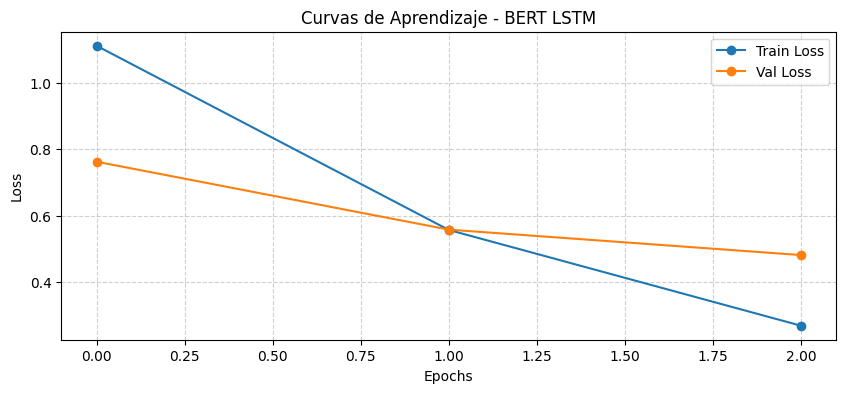


--- REPORTE FINAL EN TEST ---
              precision    recall  f1-score   support

           0       0.71      0.88      0.78        41
           1       0.76      0.79      0.78        48
           2       0.78      0.70      0.74        54
           3       0.83      0.73      0.77        59

    accuracy                           0.77       202
   macro avg       0.77      0.78      0.77       202
weighted avg       0.77      0.77      0.77       202



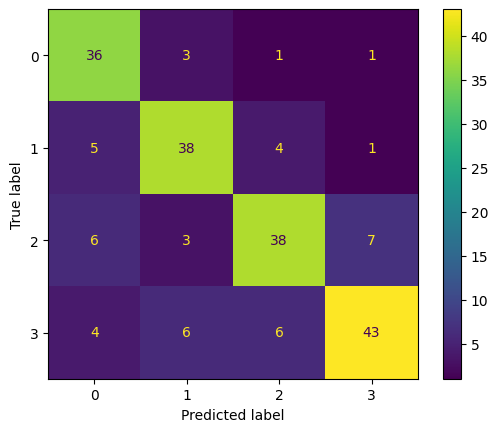

In [ ]:
# --- ENTRENAMIENTO Y EVALUACIÓN: BERT LSTM ---
print("\n" + "="*40)
print("INICIANDO FLUJO PARA BERT_LSTM")
print("="*40)

# Paso 1 y 2: Instanciar y alojar en GPU
modelo_lstm = BERT_LSTM().to(device)

# Paso 3: Entrenar el nuevo modelo
h_lstm = train_model(modelo_lstm, "Modelo 3: LSTM")

# Visualizar curvas
plt.figure(figsize=(10,4))
plt.plot(h_lstm['train_loss'], label='Train Loss', marker='o')
plt.plot(h_lstm['val_loss'], label='Val Loss', marker='o')
plt.title("Curvas de Aprendizaje - BERT LSTM")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Paso 4: Evaluar
evaluate_test(modelo_lstm)

**Mejor modelo seleccionado**

1. Métricas Globales (F1-Score Macro)
Al evaluar modelos de clasificación multiclase, el F1-Score Macro es nuestra brújula principal porque calcula el rendimiento promedio tratando a todas las clases por igual (sin importar si hay más ejemplos de una clase que de otra).

BERT CNN: 0.78

BERT LSTM: 0.77

BERT Linear: 0.75

La CNN se lleva la victoria absoluta aquí, logrando el mejor equilibrio entre Precisión (cuántos de los que predijo como clase X realmente lo eran) y Recall (cuántos de la clase X real logró encontrar).

2. Estabilidad del Aprendizaje (El problema del Overfitting)
Si observamos las "Curvas de Aprendizaje" (Loss), podemos ver exactamente cómo se comportó la arquitectura interna de cada red durante el entrenamiento:

BERT Linear: Como sospechábamos antes, sufrió de overfitting. Su curva naranja (Val Loss) bajó en la época 1, pero subió drásticamente en la época 2. El modelo dejó de aprender las reglas generales y empezó a memorizar el set de entrenamiento.

BERT LSTM: Mostró una excelente estabilidad. Su Val Loss bajó constantemente, lo que indica que la arquitectura recurrente ayudó a regularizar el modelo.

BERT CNN: Su Val Loss bajó y se estabilizó de forma muy suave. Aprendió bien y generalizó correctamente sin memorizar los datos.

3. Anatomía del Error (Matriz de Confusión)
El talón de Aquiles del modelo Linear fue la Clase 1. Si miras su reporte, el Recall para la clase 1 fue un desastroso 0.54 (de 48 ejemplos reales, solo encontró 26, confundiendo muchos con la clase 0 y la 2).

En cambio, observa cómo las otras arquitecturas resolvieron este cuello de botella:

El BERT LSTM subió ese Recall a 0.79 (acertando 38 de 48).

El BERT CNN lo llevó a 0.83 (acertando 40 de 48).

# **Analisis Extendido sobre los modelos**

El hecho de que la CNN y la LSTM superaran a la capa Linear nos revela algo fundamental sobre la naturaleza de tu dataset:

La capa Linear dependía únicamente del token [CLS] (el resumen global de la oración). Al fallar, nos indica que un simple resumen matemático de toda la frase no es suficiente para distinguir los matices entre tus 4 clases.

# **Serializar**

In [ ]:
import torch, os, json, shutil
from transformers import AutoTokenizer
from google.colab import files

MODEL_NAME = "dccuchile/bert-base-spanish-wwm-uncased"
DIRECTORIO_EXPORTACION = "./modelo_exportado"
os.makedirs(DIRECTORIO_EXPORTACION, exist_ok=True)

# Pesos
torch.save(modelo_cnn.state_dict(), f"{DIRECTORIO_EXPORTACION}/pesos_bert_cnn.pt")

# Tokenizador
AutoTokenizer.from_pretrained(MODEL_NAME).save_pretrained(f"{DIRECTORIO_EXPORTACION}/tokenizador")

# Metadatos con tus clases reales
metadatos = {
    "model_name": MODEL_NAME,
    "num_clases": 4,
    "max_length": 128,
    "arquitectura": "BERT_CNN",
    "mapa_etiquetas": {
        "0": "Algoritmia y Estructuras de Datos",
        "1": "Arquitectura de Computadoras y Sistemas",
        "2": "Ingeniería de Software, Bases de Datos y Ciberseguridad",
        "3": "Computación Inteligente y Sistemas Distribuidos"
    }
}
with open(f"{DIRECTORIO_EXPORTACION}/metadatos.json", "w", encoding="utf-8") as f:
    json.dump(metadatos, f, ensure_ascii=False, indent=2)

# Comprimir y descargar
shutil.make_archive("./modelo_exportado", "zip", DIRECTORIO_EXPORTACION)
files.download("./modelo_exportado.zip")
print("✅ Listo — revisa tu carpeta de Descargas")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Listo — revisa tu carpeta de Descargas
